In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import (
    f_oneway,
    levene,
    shapiro
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [15]:
np.random.seed(1)

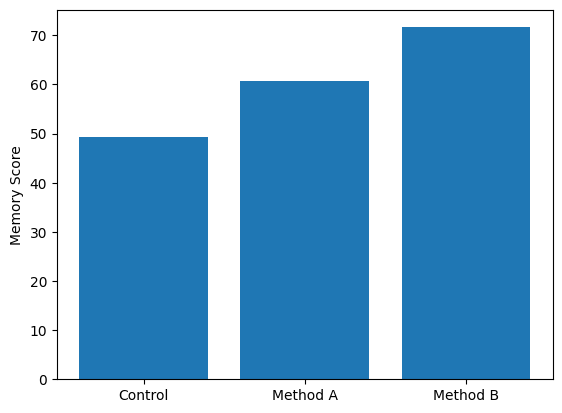

F: 43.35281207388883
p value: 8.653338797437109e-14
LeveneResult(statistic=np.float64(0.8110126948937149), pvalue=np.float64(0.4477388589068325))
ShapiroResult(statistic=np.float64(0.9733761863941449), pvalue=np.float64(0.6350365052643969))
ShapiroResult(statistic=np.float64(0.9485236031465956), pvalue=np.float64(0.1543254457841795))
ShapiroResult(statistic=np.float64(0.979541598436408), pvalue=np.float64(0.8132359660616193))


In [16]:
# Simulating data.

control = np.random.normal(loc=50, scale=10, size=30)

method_a = np.random.normal(loc=60, scale=10, size=30)

method_b = np.random.normal(loc=70, scale=10, size=30)

# Visualizing group means.

means = [
    control.mean(),
    method_a.mean(),
    method_b.mean()
]

plt.bar(
    ["Control",
     "Method A",
     "Method B"],
    means
)

plt.ylabel("Memory Score")

plt.show()

# Running one-way ANOVA.

F, p = f_oneway(
    control,
    method_a,
    method_b
)

print("F:", F)
print("p value:", p)

# Levene for checking homogeneity of variance.

print(
    levene(
        control,
        method_a,
        method_b
    )
)

# Shapiro for checking normality.

print(shapiro(control))
print(shapiro(method_a))
print(shapiro(method_b))

ANOVA Assumptions

- Independence : participants should be independent.
- Normality: each group's residuals should be normal.
- Homogeneity of Varianceroup variances should be similar.

Note: after a significant ANOVA use pairwise comparisons like Tukey HSD.

In [18]:
# Creating dataframe.

scores = np.concatenate([control, method_a, method_b])

group = (
    ["Control"]*30 +
    ["MethodA"]*30 +
    ["MethodB"]*30
)

df = pd.DataFrame({
    "score": scores,
    "group": group
})

# Running Tukey.

tukey = pairwise_tukeyhsd(
    endog=df["score"],
    groups=df["group"],
    alpha=0.05
)

print("Tukey:\n", tukey)

Tukey:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Control MethodA  11.3651    0.0  5.6704 17.0597   True
Control MethodB  22.2363    0.0 16.5416  27.931   True
MethodA MethodB  10.8712 0.0001  5.1766 16.5659   True
------------------------------------------------------
